In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy as sc
import os
import neurokit2 as nk

In [2]:
df = pd.read_csv("ECGtesta.csv")

In [3]:
cyclic_height = df["Channel 2"]

time = df["Time"]

cyclic_height_cleaned = cyclic_height.dropna()

In [4]:
pd.DataFrame.describe(cyclic_height)

count    8370.000000
mean        0.367273
std         0.152651
min         0.107800
25%         0.326300
50%         0.413400
75%         0.475300
max         0.822800
Name: Channel 2, dtype: float64

In [5]:
pd.DataFrame.describe(df)

,Time,Channel 1,Channel 2,Channel 3
count,10001.000000,10001.000000,8370.000000,10001.000000
mean,5.000000,79.964287,0.367273,0.000307
std,2.887184,1.211044,0.152651,0.060299
min,0.000000,76.530000,0.107800,-0.426000
25%,2.500000,79.070000,0.326300,-0.015000
50%,5.000000,79.830000,0.413400,0.000000
75%,7.500000,80.800000,0.475300,0.013000
max,10.000000,83.850000,0.822800,0.425000


In [6]:
avg_cyclic_height_c = cyclic_height_cleaned.mean()

In [7]:
count_above_average = cyclic_height_cleaned > avg_cyclic_height_c.sum()

In [8]:
print(count_above_average)

1631      True
1632      True
1633      True
1634      True
1635      True
         ...  
9996     False
9997     False
9998     False
9999     False
10000    False
Name: Channel 2, Length: 8370, dtype: bool


In [9]:
Number_of_values_above_avg = count_above_average.sum()

In [10]:
print("Count of values above the average:", Number_of_values_above_avg)

Count of values above the average: 4217


In [11]:
print(f"Count of values above the average: {Number_of_values_above_avg}")

Count of values above the average: 4217


In [12]:
4877/9982

0.4885794429973953

<Axes: xlabel='Channel 3', ylabel='Count'>

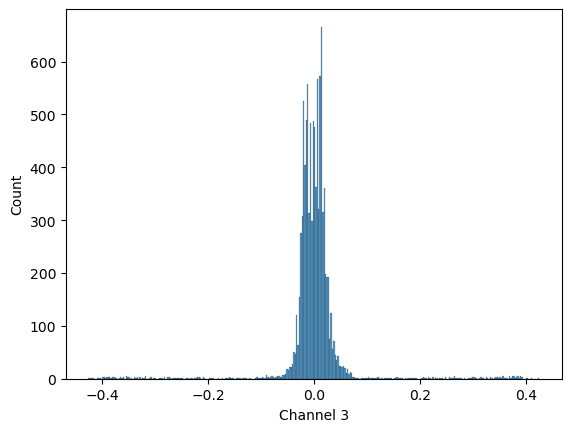

In [43]:
sns.histplot(data=df, x = "Channel 3")

In [14]:
# Calculating # of samples per second
Number_of_samples_in1second = time <= 1.0

<Axes: xlabel='Time', ylabel='Channel 3'>

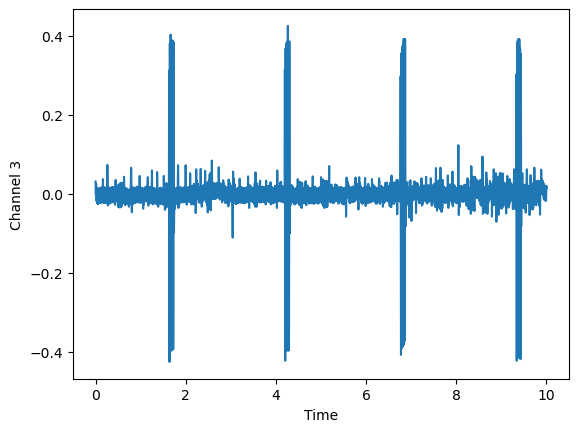

In [15]:
sns.lineplot(data=df, x = "Time" , y = "Channel 3")

In [16]:
print(df.head())

    Time  Channel 1   Channel 2  Channel 3
0  0.000       82.77        NaN      0.031
1  0.001       82.79        NaN      0.023
2  0.002       82.76        NaN      0.015
3  0.003       82.73        NaN      0.009
4  0.004       82.73        NaN      0.003


In [17]:
# Making a dataframe for each second hard way
# f_df = df.iloc[0:1001]
# s_df = df.iloc[1001:2001]
# t_df = df.iloc[2001:3001]
# f_df = df.iloc[3001:4001]

In [18]:
# Chunking my data
chunk_size = 1001  # Size of each smaller chunk
num_chunks = 10  # Number of chunks you want

# Split the dataframe into smaller dataframes
dfs = [df.iloc[i*chunk_size : (i+1)*chunk_size] for i in range(num_chunks)]

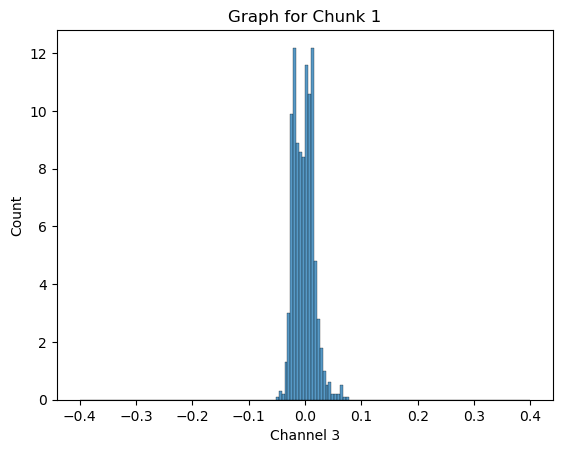

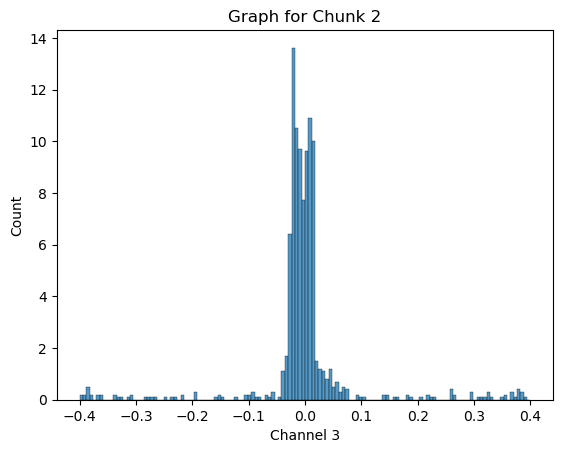

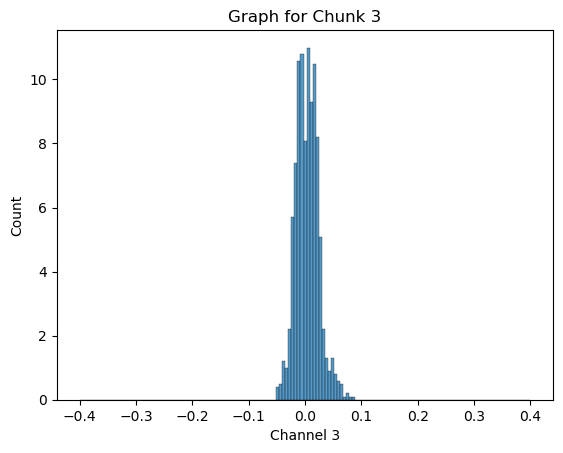

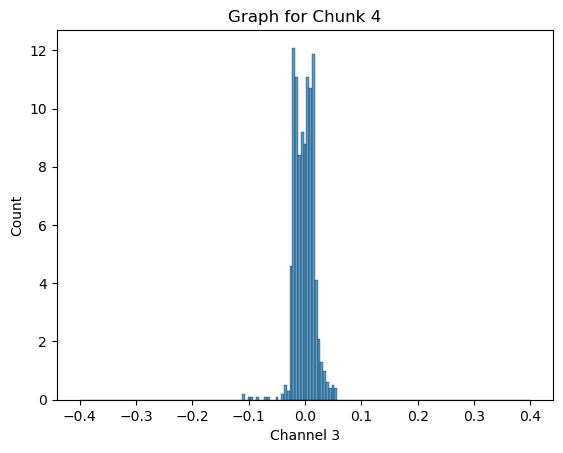

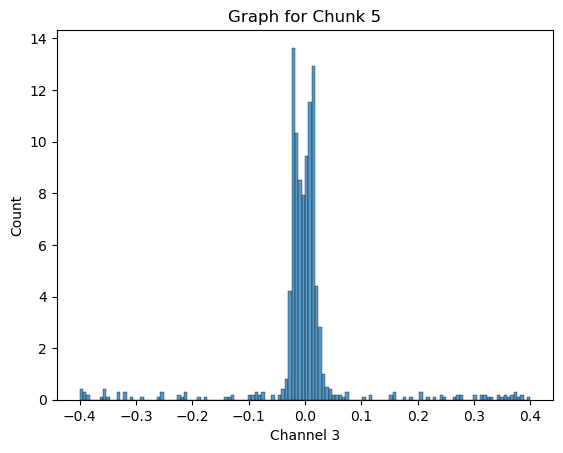

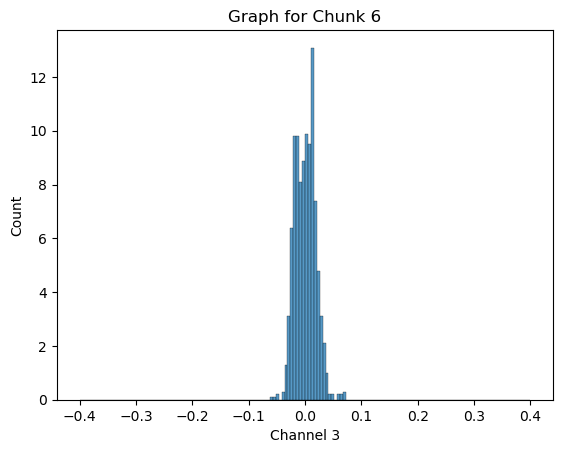

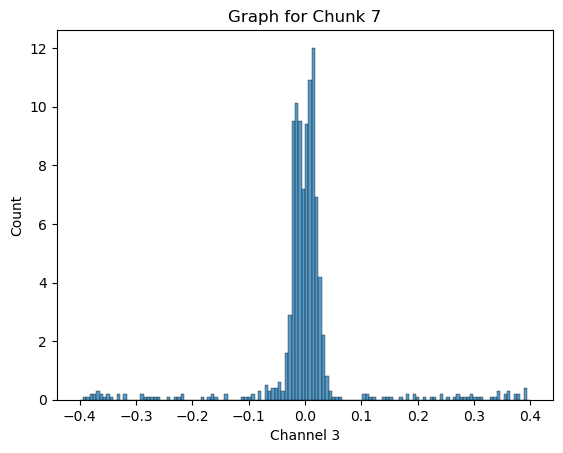

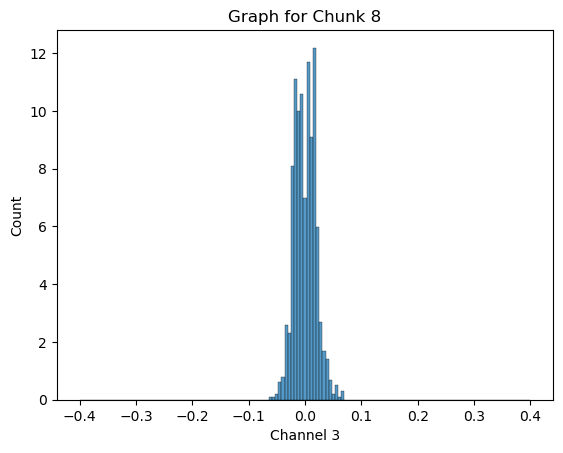

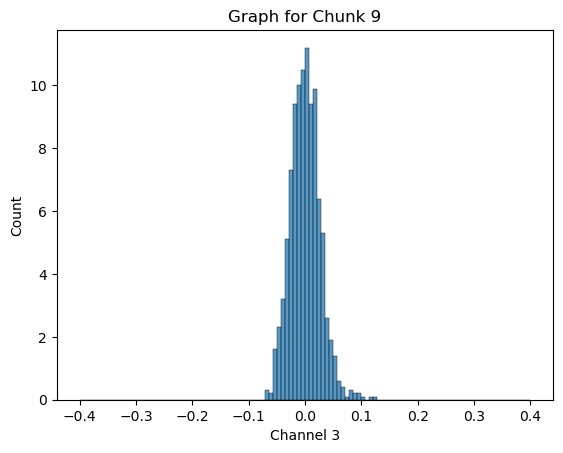

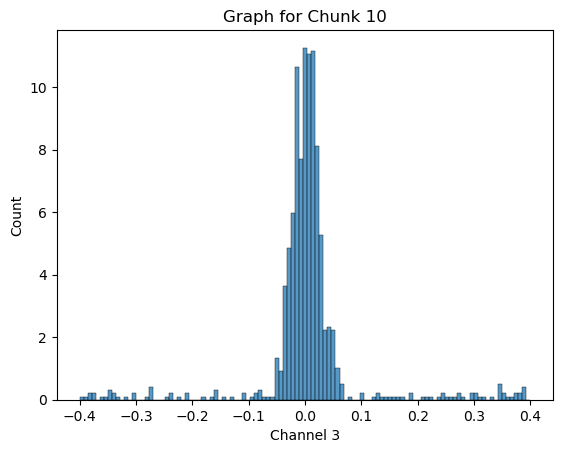

In [42]:
# Now we iterate over the list 'dfs' to generate individual plots
for i, chunk_df in enumerate(dfs):
    # Create a new figure for each plot
    plt.figure()
    
    # Seaborn example plot: plotting all columns (you can customize this based on your data)
    sns.histplot(data=chunk_df,  x='Channel 3', stat = 'percent', binrange = (-0.4 , 0.4))  # Modify based on your columns
    
    # Add titles or labels specific to each chunk
    plt.title(f"Graph for Chunk {i+1}")
    plt.xlabel("Channel 3")  # Replace with actual column name if necessary
    plt.ylabel("Count")  # Replace with actual column name if necessary
    
    # Show the plot
    plt.show()

In [35]:
Number_of_samples_above = df['Channel 3'] > 0.1

In [34]:
Number_of_samples_below = df['Channel 3'] < -0.1

In [37]:
above_below = Number_of_samples_below + Number_of_samples_above

In [39]:
above_below_sum = above_below.sum()

In [40]:
print(above_below_sum)

368


In [44]:
print(df['Channel 3'].count())

10001


In [45]:
368/10001*100

3.67963203679632